# Validation TitanTPP Classic Notebook

- `mark = log10 order class`, `value = residual regression` 구조로 데이터를 재구성하기
- RMTPP regression baseline과 TitanTPP regression 모델을 classic event-count lookback 조건에서 같은 split으로 학습하기
- validation loss 기반으로 학습 상태를 비교하기
- validation 샘플 한 건에 대해 다음 이벤트의 분포를 `mark / dt / qty` 관점에서 시각화하기


In [1]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
from IPython.display import display

PROJECT_ROOT = Path('~/workspace/paper_research').expanduser().resolve()

assert (PROJECT_ROOT / 'models').exists(), f'Invalid PROJECT_ROOT: {PROJECT_ROOT}'
assert (PROJECT_ROOT / 'utils').exists(), f'Invalid PROJECT_ROOT: {PROJECT_ROOT}'
assert (PROJECT_ROOT / 'sample_data').exists(), f'Invalid PROJECT_ROOT: {PROJECT_ROOT}'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from models.RMTPPs.config import RMTPPConfig
from models.Titan import TitanConfig
from utils.magnitude_pipeline import build_magnitude_marked_df
from utils.training import (
    TrainingConfig,
    make_classic_next_event_loaders,
    train_rmtpp_classic,
    train_titantpp_classic,
)

SEED = 22
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('DEVICE =', DEVICE)


PROJECT_ROOT = /home/leekwanhyeong/workspace/paper_research
DEVICE = cuda


## 1. Raw Data Load

먼저 원본 parquet를 읽고, 필요하면 일부 part만 골라서 빠르게 실험할 수 있게 합니다.


In [2]:
PARQUET_PATH = PROJECT_ROOT / 'sample_data' / 'intermittent_df.parquet'

# Set PART_LIMIT to an integer for a quick smoke test.
# Leave it as None when you want to train on the full table.
PART_LIMIT = None

raw_df = pl.read_parquet(PARQUET_PATH)
if PART_LIMIT is not None:
    selected_parts = raw_df.select('oper_part_no').unique().head(PART_LIMIT)['oper_part_no'].to_list()
    raw_df = raw_df.filter(pl.col('oper_part_no').is_in(selected_parts))

print('raw rows =', raw_df.height)
print('unique parts =', raw_df.select('oper_part_no').n_unique())
display(raw_df.head())


raw rows = 6830468
unique parts = 23387


demand_dt,demand_qty,seq,oper_part_no
i64,f64,u32,str
201811,2.0,1,"""0001-1002"""
201812,0.0,2,"""0001-1002"""
201813,0.0,3,"""0001-1002"""
201814,0.0,4,"""0001-1002"""
201815,0.0,5,"""0001-1002"""


## 2. Magnitude-Factorised Label Build

`mark`를 기존 quantile bin이 아니라 `floor(log10(demand_qty))` 기반 오더 클래스로 구성.
그리고 `scale_residual = log10(qty) - mark`를 regression target으로 함께 생성.


In [3]:
marked_df, meta = build_magnitude_marked_df(raw_df)

print('suggested max_order =', meta['max_order'])
print('num_marks (including PAD) =', meta['num_marks'])

print('[Raw order distribution]')
display(meta['raw_distribution'])

print('[Marked distribution after merge/cap]')
display(meta['marked_distribution'])

print('[Training table preview]')
display(
    marked_df.select([
        'oper_part_no',
        'demand_dt',
        'seq',
        'delta_t',
        'demand_qty',
        'log10_qty',
        'scale_residual',
        'mark',
    ]).head(10)
)


suggested max_order = 3
num_marks (including PAD) = 5
[Raw order distribution]


raw_order,len,ratio,cum_ratio
i32,u32,f64,f64
0,215127,0.885705,0.885705
1,26117,0.107527,0.993231
2,1540,0.00634,0.999572
3,104,0.000428,1.0


[Marked distribution after merge/cap]


mark,len
i32,u32
0,215127
1,26117
2,1540
3,104


[Training table preview]


oper_part_no,demand_dt,seq,delta_t,demand_qty,log10_qty,scale_residual,mark
str,i64,u32,i32,f64,f64,f64,i32
"""0001-1002""",201811,1,0,2.0,0.30103,0.30103,0
"""0001-1002""",201902,44,43,1.0,0.0,0.0,0
"""0001-1002""",202309,260,216,1.0,0.0,0.0,0
"""0001-1002""",202312,263,3,1.0,0.0,0.0,0
"""0001-1002""",202609,416,153,1.0,0.0,0.0,0
"""0001-1002""",202612,419,3,1.0,0.0,0.0,0
"""0011-2-1-04""",201803,1,0,10.0,1.0,0.0,1
"""0011-2-1-04""",202102,157,156,10.0,1.0,0.0,1
"""0011-2-1-04""",202104,159,2,10.0,1.0,0.0,1


## 3. Classic Training Configuration

여기서는 `lookback`을 최근 `W주`가 아니라 **최근 `L개 이벤트`** 의미로 사용합니다.
즉 classic RMTPP next-event 설정과 같은 fixed event-count context입니다.


In [8]:
training_config = TrainingConfig(
    lookback=5,
    max_seq_len=64,  # unused in the classic path; kept for config parity
    batch_size=256,
    lr=3e-4,
    epochs=15,
    val_ratio=0.2,
    device=DEVICE,
    lambda_value=1.0,
    lambda_dt=1.0,
    grad_clip=1.0,
)

rmtpp_config = RMTPPConfig(
    num_marks=meta['num_marks'],
    mark_emb_dim=32,
    rnn_hidden_dim=64,
    rnn_type='gru',
    dropout=0.1,
)

titan_config = TitanConfig(
    d_model=64,
    n_layers=2,
    n_heads=4,
    d_ff=128,
    contextual_mem_size=16,
    persistent_mem_size=16,
    dropout=0.1,
    use_lmm=True,
    mem_size=64,
    mem_topk=4,
    use_causal=True,
)

print(training_config)
print(rmtpp_config)
print(titan_config)


TrainingConfig(lookback=5, max_seq_len=64, batch_size=256, lr=0.0003, epochs=15, val_ratio=0.2, device='cuda', lambda_value=1.0, lambda_dt=1.0, grad_clip=1.0)
RMTPPConfig(num_marks=5, mark_emb_dim=32, rnn_hidden_dim=64, rnn_type='gru', dropout=0.1, use_value_head=True, value_head_activation='sigmoid', eps=1e-08, w_min=0.001, exp_clamp=300.0)
TitanConfig(lookback=52, horizon=27, past_exo_cont_dim=0, past_exo_cat_dims=None, past_exo_cat_embed_dims=None, final_clamp_nonneg=False, exo_dim=0, d_model=64, n_layers=2, n_heads=4, d_ff=128, dropout=0.1, contextual_mem_size=16, persistent_mem_size=16, use_context_update=False, use_pos_emb=True, max_len=512, use_lmm=True, mem_size=64, mem_topk=4, use_causal=True, use_revin=True, clamp_min=0.0, clamp_max=None)


In [9]:
train_loader, val_loader = make_classic_next_event_loaders(marked_df, training_config)

print('train samples =', len(train_loader.dataset))
print('val samples =', len(val_loader.dataset))

batch = next(iter(train_loader))
x_mk, x_dt, y_mk, y_dt, part_idx, x_val, y_val = batch
print('x_mk shape =', tuple(x_mk.shape))
print('x_dt shape =', tuple(x_dt.shape))
print('y_mk shape =', tuple(y_mk.shape))
print('y_dt shape =', tuple(y_dt.shape))
print('x_val shape =', None if x_val is None else tuple(x_val.shape))
print('y_val shape =', None if y_val is None else tuple(y_val.shape))


train samples = 102093
val samples = 45311
x_mk shape = (256, 5)
x_dt shape = (256, 5)
y_mk shape = (256,)
y_dt shape = (256,)
x_val shape = (256, 5)
y_val shape = (256,)


## 4. RMTPP Classic Training

이 셀은 classic event-count lookback 위에서 `mark classification + residual regression + dt likelihood`를 함께 학습하는 RMTPP baseline을 실행합니다.


In [10]:
rmtpp_model, rmtpp_info = train_rmtpp_classic(
    marked_df=marked_df,
    training_config=training_config,
    rmtpp_config=rmtpp_config,
)

print('RMTPP classic best_score =', rmtpp_info['best_score'])
print('RMTPP classic history length =', len(rmtpp_info['history']))


/home/leekwanhyeong/miniconda3/envs/ai_env/lib/python3.12/site-packages/torch/nn/modules/rnn.py:1364: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


[Epoch 01] train_loss=35.60512337 | val_acc=0.90364371 val_dt_mae=27.82572594 | val_dt_rmse=33.30754086 | val_value_mae=0.23573841 | val_qty_mae=5.68369386 | val_nll_time=8.793626 val_nll_marker=0.251645 val_value_loss=0.037034 val_nll=9.045271 | total=45311 | correct=40945 | steps=45311
[Epoch 02] train_loss=5.27624231 | val_acc=0.93070115 val_dt_mae=26.10984146 | val_dt_rmse=32.01150118 | val_value_mae=0.23471901 | val_qty_mae=5.64859310 | val_nll_time=7.137813 val_nll_marker=0.177332 val_value_loss=0.036468 val_nll=7.315145 | total=45311 | correct=42171 | steps=45311
[Epoch 03] train_loss=4.88367958 | val_acc=0.93385712 val_dt_mae=24.97320626 | val_dt_rmse=31.54037452 | val_value_mae=0.23407713 | val_qty_mae=5.49903910 | val_nll_time=6.436166 val_nll_marker=0.168698 val_value_loss=0.036320 val_nll=6.604864 | total=45311 | correct=42314 | steps=45311
[Epoch 04] train_loss=4.66982753 | val_acc=0.93297433 val_dt_mae=24.86265614 | val_dt_rmse=32.00187162 | val_value_mae=0.23382571 | val

## 5. TitanTPP Classic Training

이 셀은 같은 classic target 구조 위에서 Titan backbone을 사용하는 TitanTPP를 학습합니다.


In [11]:
titan_model, titan_info = train_titantpp_classic(
    marked_df=marked_df,
    training_config=training_config,
    rmtpp_config=rmtpp_config,
    titan_config=titan_config,
)

print('TitanTPP classic best_score =', titan_info['best_score'])
print('TitanTPP classic history length =', len(titan_info['history']))


[Epoch 01] train_loss=13.98042418 | val_acc=0.92913421 val_dt_mae=29.56721579 | val_dt_rmse=35.59480047 | val_value_mae=0.23686042 | val_qty_mae=5.73258964 | val_nll_time=7.536594 val_nll_marker=0.170115 val_value_loss=0.036935 val_nll=7.706709 | total=45311 | correct=42100 | steps=45311
[Epoch 02] train_loss=5.41390750 | val_acc=0.93178257 val_dt_mae=27.97660318 | val_dt_rmse=33.75589562 | val_value_mae=0.23604315 | val_qty_mae=5.82567076 | val_nll_time=7.001776 val_nll_marker=0.162649 val_value_loss=0.036629 val_nll=7.164425 | total=45311 | correct=42220 | steps=45311
[Epoch 03] train_loss=5.07120602 | val_acc=0.93414403 val_dt_mae=27.45383707 | val_dt_rmse=33.43119244 | val_value_mae=0.23563532 | val_qty_mae=5.50482548 | val_nll_time=6.555771 val_nll_marker=0.159955 val_value_loss=0.036633 val_nll=6.715726 | total=45311 | correct=42327 | steps=45311
[Epoch 04] train_loss=4.85993145 | val_acc=0.93257708 val_dt_mae=27.25699436 | val_dt_rmse=33.56823684 | val_value_mae=0.23495709 | val

## 6. Loss-Based Validation Comparison

epoch별 `train_loss`, `val_nll`, `val_value_loss`, `dt_mae`, `qty_mae`, `mark_acc`를 같이 비교합니다.


[RMTPP classic history]


epoch,train_loss,score,mark_acc,dt_mae,dt_rmse,value_mae,qty_mae,val_nll_time,val_nll_marker,val_nll,val_value_loss,_total,_correct,_nll_steps,model
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,35.605123,0.619703,0.903644,27.825726,33.307541,0.235738,5.683694,8.793626,0.251645,9.045271,0.037034,45311.0,40945.0,45311.0,"""RMTPP"""
2,5.276242,0.663954,0.930701,26.109841,32.011501,0.234719,5.648593,7.137813,0.177332,7.315145,0.036468,45311.0,42171.0,45311.0,"""RMTPP"""
3,4.88368,0.678626,0.933857,24.973206,31.540375,0.234077,5.499039,6.436166,0.168698,6.604864,0.03632,45311.0,42314.0,45311.0,"""RMTPP"""
4,4.669828,0.67885,0.932974,24.862656,32.001872,0.233826,5.497281,5.731161,0.16644,5.8976,0.036193,45311.0,42274.0,45311.0,"""RMTPP"""
5,4.532651,0.685207,0.932687,24.20119,31.949248,0.23394,5.468689,5.569944,0.164553,5.734496,0.036155,45311.0,42261.0,45311.0,"""RMTPP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,4.15362,0.699871,0.934674,22.944131,31.486738,0.233433,5.361285,4.718996,0.158473,4.877469,0.035852,45311.0,42351.0,45311.0,"""RMTPP"""
12,4.114991,0.702865,0.934806,22.635475,31.179638,0.234052,5.586102,4.612079,0.159092,4.77117,0.035957,45311.0,42357.0,45311.0,"""RMTPP"""
13,4.081029,0.707059,0.934166,22.173512,31.058112,0.233503,5.372231,4.577684,0.157962,4.735646,0.035822,45311.0,42328.0,45311.0,"""RMTPP"""


[TitanTPP classic history]


epoch,train_loss,score,mark_acc,dt_mae,dt_rmse,value_mae,qty_mae,val_nll_time,val_nll_marker,val_nll,val_value_loss,_total,_correct,_nll_steps,model
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,13.980424,0.627729,0.929134,29.567216,35.5948,0.23686,5.73259,7.536594,0.170115,7.706709,0.036935,45311.0,42100.0,45311.0,"""TitanTPP"""
2,5.413908,0.646191,0.931783,27.976603,33.755896,0.236043,5.825671,7.001776,0.162649,7.164425,0.036629,45311.0,42220.0,45311.0,"""TitanTPP"""
3,5.071206,0.654101,0.934144,27.453837,33.431192,0.235635,5.504825,6.555771,0.159955,6.715726,0.036633,45311.0,42327.0,45311.0,"""TitanTPP"""
4,4.859931,0.654866,0.932577,27.256994,33.568237,0.234957,5.141425,5.558665,0.159324,5.717989,0.036348,45311.0,42256.0,45311.0,"""TitanTPP"""
5,4.689307,0.672948,0.933085,25.496603,31.931879,0.234454,5.170825,5.375575,0.157099,5.532674,0.036354,45311.0,42279.0,45311.0,"""TitanTPP"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,4.232212,0.702449,0.935821,22.784231,31.031192,0.235342,5.529993,4.635244,0.154772,4.790016,0.036268,45311.0,42403.0,45311.0,"""TitanTPP"""
12,4.199899,0.702297,0.934365,22.669966,30.892899,0.234854,5.367863,4.493929,0.155852,4.649781,0.036202,45311.0,42337.0,45311.0,"""TitanTPP"""
13,4.173135,0.709446,0.935667,22.060016,31.298604,0.235038,5.620422,4.595911,0.15393,4.749841,0.036206,45311.0,42396.0,45311.0,"""TitanTPP"""


[Best epochs by score / val_nll]


model,selection,epoch,score,train_loss,val_nll,val_value_loss,mark_acc,dt_mae,qty_mae
str,str,i64,f64,f64,f64,f64,f64,f64,f64
"""RMTPP""","""best_score""",15,0.714337,4.022311,4.665373,0.035917,0.934321,21.459052,5.393037
"""RMTPP""","""best_val_nll""",15,0.714337,4.022311,4.665373,0.035917,0.934321,21.459052,5.393037
"""TitanTPP""","""best_score""",14,0.712487,4.139627,5.072093,0.036887,0.934541,21.661263,5.441576
"""TitanTPP""","""best_val_nll""",15,0.70104,4.106012,4.512069,0.036202,0.934541,22.815379,5.347905


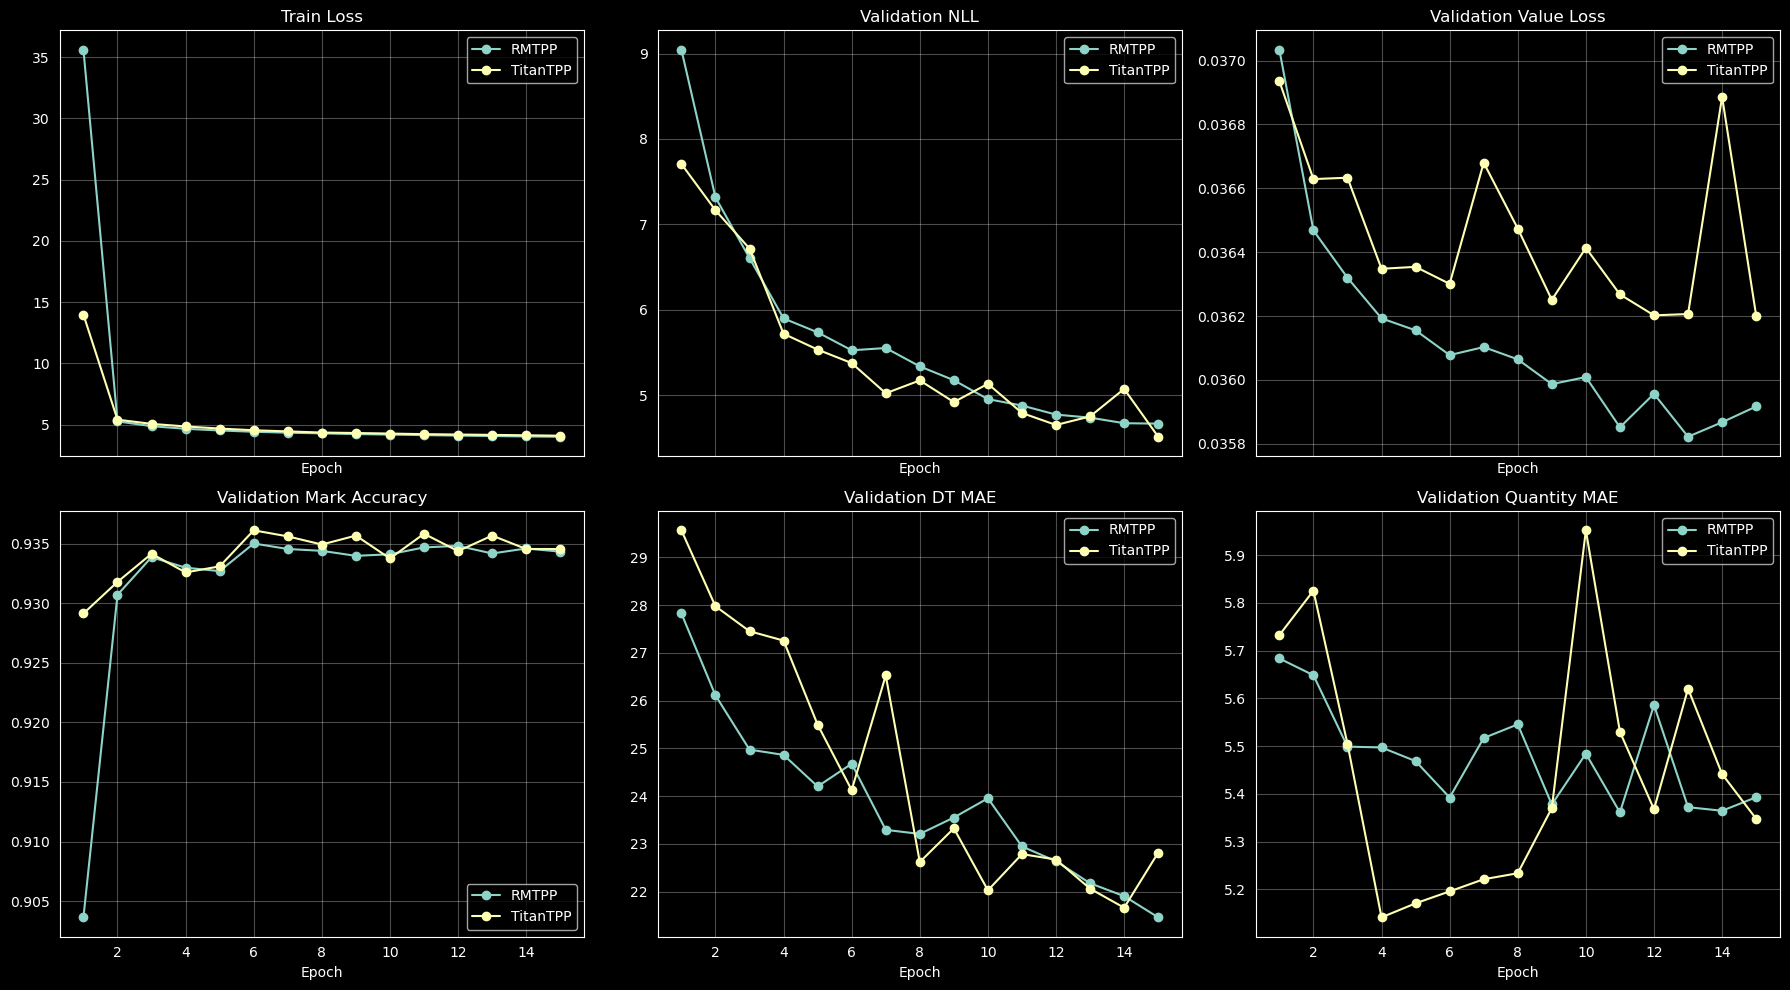

In [12]:
rmtpp_hist = pl.DataFrame(rmtpp_info['history']).with_columns(pl.lit('RMTPP').alias('model'))
titan_hist = pl.DataFrame(titan_info['history']).with_columns(pl.lit('TitanTPP').alias('model'))

print('[RMTPP classic history]')
display(rmtpp_hist)
print('[TitanTPP classic history]')
display(titan_hist)

def best_epoch(hist_df: pl.DataFrame, metric: str, descending: bool) -> pl.DataFrame:
    return hist_df.sort(metric, descending=descending).head(1)

summary_table = pl.concat([
    best_epoch(rmtpp_hist, 'score', True).with_columns(pl.lit('best_score').alias('selection')),
    best_epoch(rmtpp_hist, 'val_nll', False).with_columns(pl.lit('best_val_nll').alias('selection')),
    best_epoch(titan_hist, 'score', True).with_columns(pl.lit('best_score').alias('selection')),
    best_epoch(titan_hist, 'val_nll', False).with_columns(pl.lit('best_val_nll').alias('selection')),
], how='diagonal').select([
    'model',
    'selection',
    'epoch',
    'score',
    'train_loss',
    'val_nll',
    'val_value_loss',
    'mark_acc',
    'dt_mae',
    'qty_mae',
])

print('[Best epochs by score / val_nll]')
display(summary_table)

metric_specs = [
    ('train_loss', 'Train Loss'),
    ('val_nll', 'Validation NLL'),
    ('val_value_loss', 'Validation Value Loss'),
    ('mark_acc', 'Validation Mark Accuracy'),
    ('dt_mae', 'Validation DT MAE'),
    ('qty_mae', 'Validation Quantity MAE'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
for ax, (metric, title) in zip(axes.ravel(), metric_specs):
    for label, history in [('RMTPP', rmtpp_info['history']), ('TitanTPP', titan_info['history'])]:
        epochs = [int(row['epoch']) for row in history]
        values = [float(row[metric]) for row in history]
        ax.plot(epochs, values, marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


## 7. Validation Next-Sample Distribution

classic validation 샘플 하나를 고른 뒤, RMTPP와 TitanTPP가 다음 이벤트를 어떻게 다르게 보고 있는지 `mark / dt / qty` 분포로 비교..


In [13]:
_, val_loader = make_classic_next_event_loaders(marked_df, training_config)

def pick_validation_sample_classic(val_loader, sample_index: int = 0):
    dataset = val_loader.dataset
    seen = 0

    for x_mk, x_dt, y_mk, y_dt, part_idx, x_val, y_val in val_loader:
        batch_size = x_mk.size(0)
        for local_idx in range(batch_size):
            if seen == sample_index:
                global_part_idx = int(part_idx[local_idx].item())
                return {
                    'x_mk': x_mk[local_idx:local_idx + 1].to(DEVICE),
                    'x_dt': x_dt[local_idx:local_idx + 1].to(DEVICE),
                    'y_mk': y_mk[local_idx:local_idx + 1].to(DEVICE),
                    'y_dt': y_dt[local_idx:local_idx + 1].to(DEVICE),
                    'x_val': None if x_val is None else x_val[local_idx:local_idx + 1].to(DEVICE),
                    'y_val': None if y_val is None else y_val[local_idx:local_idx + 1].to(DEVICE),
                    'part_idx': global_part_idx,
                    'oper_part_no': dataset.parts[global_part_idx],
                }
            seen += 1

    raise RuntimeError('Requested validation sample index was out of range.')


def sample_to_event_frame_classic(sample: dict) -> pl.DataFrame:
    rows = []

    x_mk = sample['x_mk'][0].detach().cpu().tolist()
    x_dt = sample['x_dt'][0].detach().cpu().tolist()
    x_val = None if sample['x_val'] is None else sample['x_val'][0].detach().cpu().tolist()

    for pos, (mark, dt) in enumerate(zip(x_mk, x_dt)):
        value = None if x_val is None else float(x_val[pos])
        qty = None if value is None else float(10.0 ** (mark + value))
        rows.append({
            'role': 'context',
            'position': pos,
            'mark': int(mark),
            'delta_t': float(dt),
            'scale_residual': value,
            'reconstructed_qty': qty,
        })

    y_mark = int(sample['y_mk'][0].item())
    y_dt = float(sample['y_dt'][0].item())
    y_val = None if sample['y_val'] is None else float(sample['y_val'][0].item())
    y_qty = None if y_val is None else float(10.0 ** (y_mark + y_val))
    rows.append({
        'role': 'target',
        'position': len(x_mk),
        'mark': y_mark,
        'delta_t': y_dt,
        'scale_residual': y_val,
        'reconstructed_qty': y_qty,
    })

    return pl.DataFrame(rows)


def analyze_next_sample_distribution_classic(model, sample: dict, model_name: str, n_dt_samples: int = 4000, n_mark_samples: int = 4000):
    model.eval()

    x_mk = sample['x_mk']
    x_dt = sample['x_dt']
    y_mk = sample['y_mk']
    y_dt = sample['y_dt']
    y_val = sample['y_val']

    with torch.no_grad():
        h = model.forward(x_mk, x_dt)
        h_last = h[:, -1, :]

        logits = model.mark_head(h_last)[..., : model.cfg.num_marks - 1]
        mark_prob = torch.softmax(logits, dim=-1).squeeze(0)

        value_hat = model.predict_value(h_last).squeeze(0)

        dt_samples = model.sample_next_dt(h_last.repeat(n_dt_samples, 1)).detach().cpu().numpy()

        mark_samples = torch.multinomial(mark_prob.repeat(n_mark_samples, 1), num_samples=1).squeeze(-1)
        value_samples = value_hat.repeat(n_mark_samples)
        qty_samples = model.reconstruct_qty(mark_samples, value_samples).detach().cpu().numpy()

        qty_support = model.reconstruct_qty(
            torch.arange(mark_prob.numel(), device=x_mk.device),
            value_hat.repeat(mark_prob.numel()),
        ).detach().cpu().numpy()

    true_mark = int(y_mk[0].item())
    true_dt = float(y_dt[0].item())
    true_value = None if y_val is None else float(y_val[0].item())
    true_qty = None if true_value is None else float(10.0 ** (true_mark + true_value))

    expected_mark = float((mark_prob * torch.arange(mark_prob.numel(), device=x_mk.device)).sum().item())
    expected_qty = float((mark_prob.detach().cpu().numpy() * qty_support).sum())

    summary = {
        'model': model_name,
        'oper_part_no': sample['oper_part_no'],
        'lookback_events': int(x_mk.size(1)),
        'true_mark': true_mark,
        'true_dt': true_dt,
        'true_scale_residual': true_value,
        'true_qty': true_qty,
        'pred_top_mark': int(mark_prob.argmax().item()),
        'pred_expected_mark': expected_mark,
        'pred_value_residual': float(value_hat.item()),
        'pred_expected_qty': expected_qty,
        'pred_dt_mean': float(dt_samples.mean()),
        'pred_dt_q50': float(np.quantile(dt_samples, 0.5)),
        'pred_dt_q90': float(np.quantile(dt_samples, 0.9)),
    }

    return {
        'summary': summary,
        'mark_prob': mark_prob.detach().cpu().numpy(),
        'dt_samples': dt_samples,
        'qty_samples': qty_samples,
        'qty_support': qty_support,
    }


validation oper_part_no = 32240-7122-4
[Validation sample event table]


role,position,mark,delta_t,scale_residual,reconstructed_qty
str,i64,i64,f64,f64,f64
"""context""",0,0,2.0,0.778151,6.0
"""context""",1,0,2.0,0.30103,2.0
"""context""",2,0,3.0,0.477121,3.0
"""context""",3,0,42.0,0.30103,2.0
"""context""",4,0,4.0,0.845098,7.0
"""target""",5,0,1.0,0.69897,5.0


[Next-sample summary]


model,oper_part_no,lookback_events,true_mark,true_dt,true_scale_residual,true_qty,pred_top_mark,pred_expected_mark,pred_value_residual,pred_expected_qty,pred_dt_mean,pred_dt_q50,pred_dt_q90
str,str,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64
"""RMTPP""","""32240-7122-4""",5,0,1.0,0.69897,5.0,0,0.011178,0.265003,2.074416,12.26807,9.746846,26.677113
"""TitanTPP""","""32240-7122-4""",5,0,1.0,0.69897,5.0,0,0.006813,0.265128,1.971505,10.973992,8.440702,24.303097


[Mark probability comparison]


mark,RMTPP_prob,TitanTPP_prob,RMTPP_qty_support,TitanTPP_qty_support
i64,f64,f64,f64,f64
0,0.988958,0.993213,1.840784,1.841314
1,0.010926,0.00677,18.407841,18.413137
2,0.000098,0.000008,184.078354,184.131317
3,0.000019,0.000009,1840.783569,1841.313232


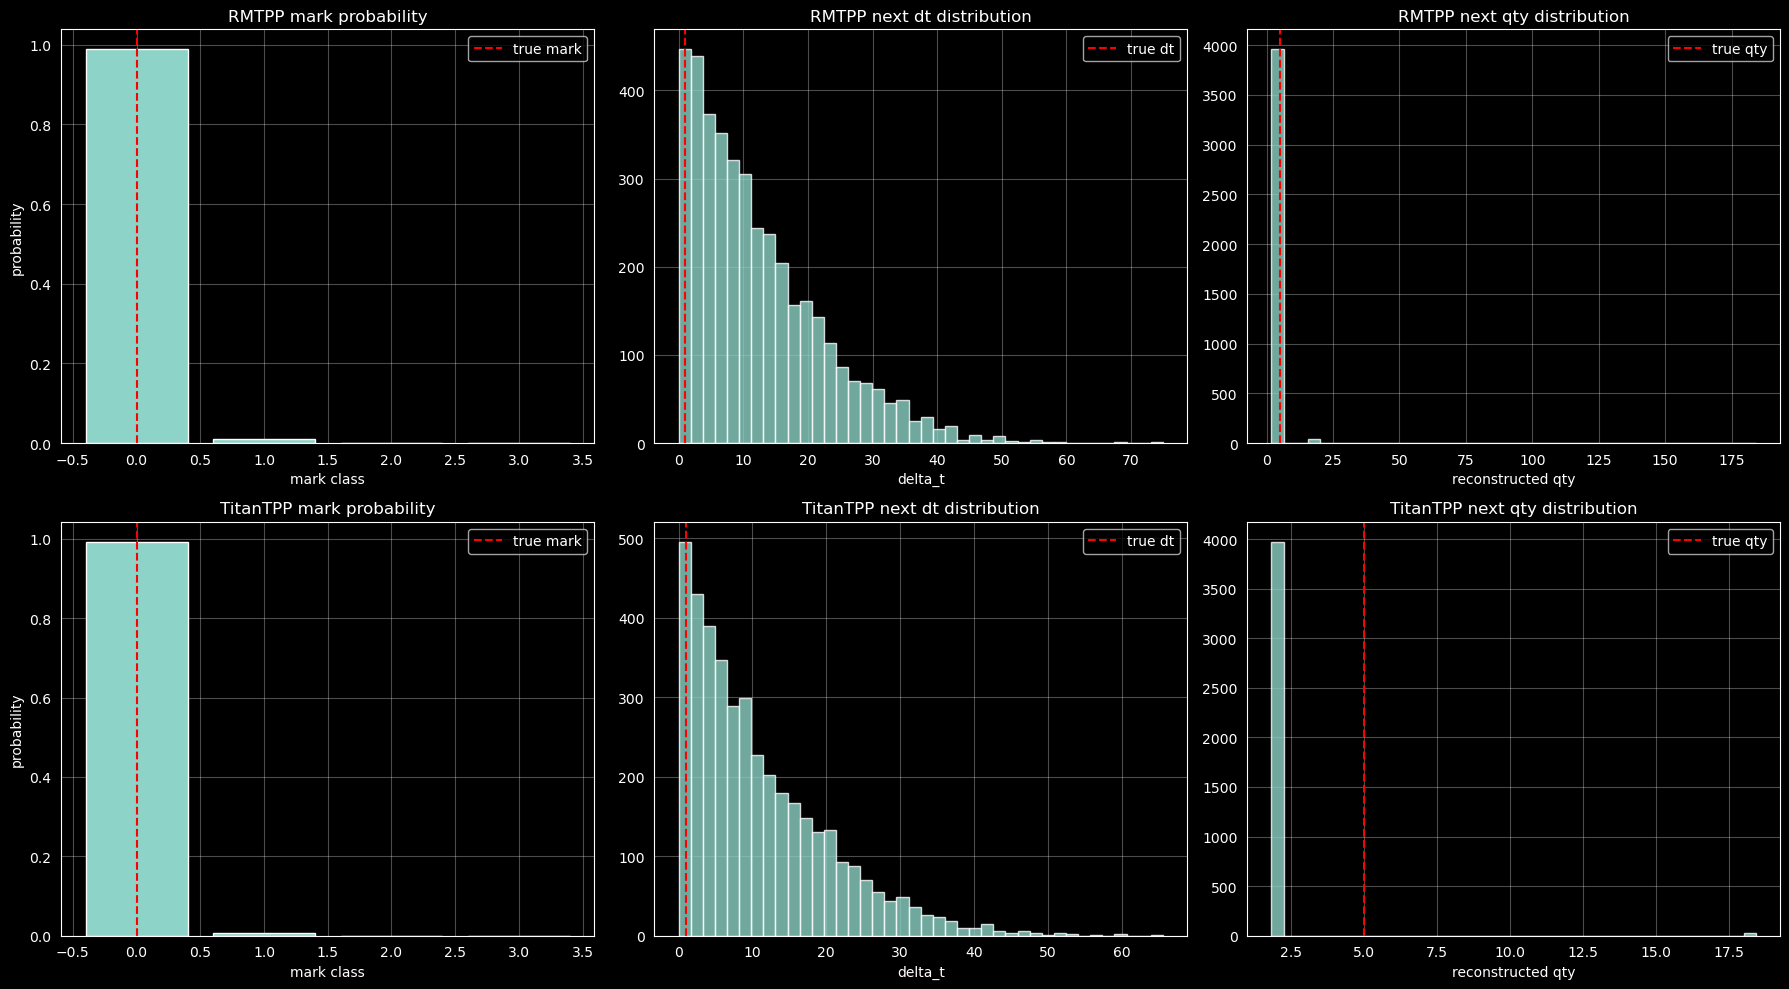

In [14]:
validation_sample = pick_validation_sample_classic(val_loader, sample_index=6)
print('validation oper_part_no =', validation_sample['oper_part_no'])

print('[Validation sample event table]')
display(sample_to_event_frame_classic(validation_sample))

rmtpp_dist = analyze_next_sample_distribution_classic(rmtpp_model, validation_sample, 'RMTPP')
titan_dist = analyze_next_sample_distribution_classic(titan_model, validation_sample, 'TitanTPP')

summary_df = pl.DataFrame([rmtpp_dist['summary'], titan_dist['summary']])
print('[Next-sample summary]')
display(summary_df)

mark_prob_df = pl.DataFrame({
    'mark': list(range(len(rmtpp_dist['mark_prob']))),
    'RMTPP_prob': rmtpp_dist['mark_prob'].tolist(),
    'TitanTPP_prob': titan_dist['mark_prob'].tolist(),
    'RMTPP_qty_support': rmtpp_dist['qty_support'].tolist(),
    'TitanTPP_qty_support': titan_dist['qty_support'].tolist(),
})
print('[Mark probability comparison]')
display(mark_prob_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_rows = [('RMTPP', rmtpp_dist), ('TitanTPP', titan_dist)]

for row_idx, (model_name, dist) in enumerate(plot_rows):
    axes[row_idx, 0].bar(np.arange(len(dist['mark_prob'])), dist['mark_prob'])
    axes[row_idx, 0].axvline(dist['summary']['true_mark'], color='red', linestyle='--', label='true mark')
    axes[row_idx, 0].set_title(f'{model_name} mark probability')
    axes[row_idx, 0].set_xlabel('mark class')
    axes[row_idx, 0].set_ylabel('probability')
    axes[row_idx, 0].grid(alpha=0.3)
    axes[row_idx, 0].legend()

    axes[row_idx, 1].hist(dist['dt_samples'], bins=40, alpha=0.8)
    axes[row_idx, 1].axvline(dist['summary']['true_dt'], color='red', linestyle='--', label='true dt')
    axes[row_idx, 1].set_title(f'{model_name} next dt distribution')
    axes[row_idx, 1].set_xlabel('delta_t')
    axes[row_idx, 1].grid(alpha=0.3)
    axes[row_idx, 1].legend()

    axes[row_idx, 2].hist(dist['qty_samples'], bins=40, alpha=0.8)
    if dist['summary']['true_qty'] is not None:
        axes[row_idx, 2].axvline(dist['summary']['true_qty'], color='red', linestyle='--', label='true qty')
    axes[row_idx, 2].set_title(f'{model_name} next qty distribution')
    axes[row_idx, 2].set_xlabel('reconstructed qty')
    axes[row_idx, 2].grid(alpha=0.3)
    axes[row_idx, 2].legend()

plt.tight_layout()
plt.show()
